# 🗣️ ShilpSetu — Auto-Cataloger: Product Category Classifier Training

**Module:** Multilingual Auto-Cataloger
**Problem Statement:** 26090 — AI-Driven Market Linkage and Smart Cataloging for Marginalized Artisans

**What this notebook builds:** a **language-agnostic product category classifier**. Rather than training directly on raw Hindi-or-English free text (which would need a huge multilingual corpus we don't have), the live app first extracts a canonical *bag of attribute tags* from whatever the artisan says — by voice note or typed text, in Hindi or English — using a curated bilingual lexicon (`data/lexicon.json`). This notebook trains a classifier on exactly that tag representation, so **the same model works regardless of the artisan's language**, with zero translation-model dependency.

**Full pipeline (implemented in `modules/auto_cataloger/app/cataloger.py`):**
1. Artisan speaks or types a product description (Hindi/English/mixed).
2. *(Optional, if available)* `faster-whisper` transcribes/translates a voice note to text — wrapped safely so the app never breaks if this optional model isn't downloaded.
3. Lexicon-based attribute extraction pulls out canonical tags (material, technique, category hints, style) from the text, in either language.
4. **This notebook's model** predicts the product category from the extracted tags.
5. A bilingual (English + Hindi) template engine generates a professional, SEO-friendly listing from the tags + predicted category.

---
## Table of Contents
1. Installing Packages
2. Import Libraries
3. Load Dataset
4. Understanding the Dataset
5. Exploratory Data Analysis (EDA)
6. Data Cleaning
7. Feature Engineering (TF-IDF over tags)
8. Data Preprocessing
9. Train-Test Split
10. Model Training & Comparison
11. Hyperparameter Tuning
12. Final Model & Evaluation
13. Save Model (.joblib)
14. Conclusion


## 1. Installing Packages

In [1]:
# Uncomment if running in a fresh environment
# %pip install pandas numpy scikit-learn matplotlib seaborn joblib -q
print("Environment ready ✅")

Environment ready ✅


## 2. Import Libraries

In [2]:
import json
import joblib
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import CalibratedClassifierCV

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


## 3. Load Dataset

We use the synthetic tag-string corpus generated from our curated bilingual handicraft lexicon (`../data/lexicon.json`, `../data/synthetic_tag_corpus.csv`).

In [3]:
df = pd.read_csv("../data/synthetic_tag_corpus.csv")
with open("../data/lexicon.json", encoding="utf-8") as f:
    lexicon = json.load(f)
with open("../data/categories.json", encoding="utf-8") as f:
    categories = json.load(f)

df.head(10)

,tag_string,category
0,warli festive canvas eco_friendly,Painting
1,bidri copper,Metalware
2,handmade basket festive bamboo,BambooCane
3,eco_friendly cane basket,BambooCane
4,handpainted_pot handmade intricate terracotta pot,Pottery
5,brass engraved_metal carved copper,Metalware
6,traditional eco_friendly leather_belt tooled_l...,Leatherwork
7,pot terracotta glazed ceramic,Pottery
8,juti tooled_leather leather_bag,Leatherwork
9,ceramic colorful traditional festive pot,Pottery


## 4. Understanding the Dataset

In [4]:
print(f"Rows: {df.shape[0]} | Categories: {df['category'].nunique()}")
print(f"\nLexicon size: {len(lexicon)} canonical tags, each with English + Hindi surface forms")
print(f"Categories: {categories}")
df['category'].value_counts()

Rows: 1760 | Categories: 8

Lexicon size: 49 canonical tags, each with English + Hindi surface forms
Categories: ['Textile', 'Pottery', 'Jewelry', 'Woodwork', 'Metalware', 'Painting', 'Leatherwork', 'BambooCane']


category
Painting       220
Metalware      220
BambooCane     220
Pottery        220
Leatherwork    220
Textile        220
Woodwork       220
Jewelry        220
Name: count, dtype: int64

## 5. Exploratory Data Analysis (EDA)

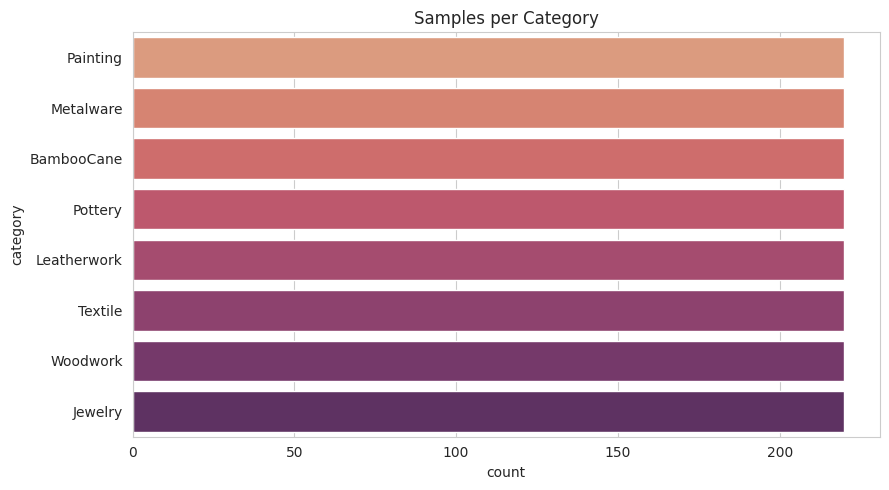

In [5]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, y='category', order=df['category'].value_counts().index, palette='flare')
plt.title("Samples per Category")
plt.tight_layout()
plt.savefig("../../../app/static/img/cataloger_class_balance.png", dpi=110)
plt.show()

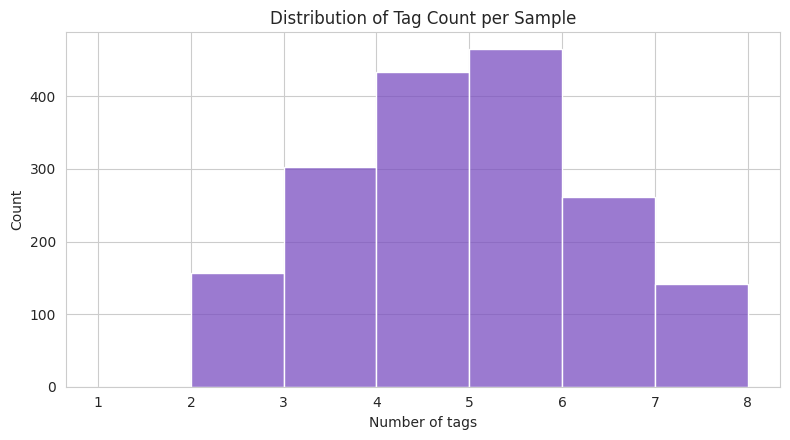

In [6]:
df['n_tags'] = df['tag_string'].str.split().apply(len)
plt.figure(figsize=(8, 4.5))
sns.histplot(df['n_tags'], bins=range(1, 9), kde=False, color='#7A4EC1')
plt.title("Distribution of Tag Count per Sample")
plt.xlabel("Number of tags")
plt.tight_layout()
plt.savefig("../../../app/static/img/cataloger_tag_distribution.png", dpi=110)
plt.show()

## 6. Data Cleaning

In [7]:
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after cleaning:", df.shape)

Missing values:
 tag_string    0
category      0
n_tags        0
dtype: int64
Duplicate rows: 105
Shape after cleaning: (1655, 3)


## 7. Feature Engineering

We vectorize the tag-strings with **TF-IDF over the tag vocabulary itself** (each tag is already a clean, canonical token — no stemming/stopwords needed, since these came straight from our controlled lexicon).

In [8]:
tfidf = TfidfVectorizer(token_pattern=r"[a-z_]+", lowercase=True)
X_tfidf = tfidf.fit_transform(df['tag_string'])
print("TF-IDF matrix shape:", X_tfidf.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))

TF-IDF matrix shape: (1655, 49)
Vocabulary size: 49


## 8. Data Preprocessing

In [9]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['category'])
print("Encoded classes:", list(label_encoder.classes_))

Encoded classes: ['BambooCane', 'Jewelry', 'Leatherwork', 'Metalware', 'Painting', 'Pottery', 'Textile', 'Woodwork']


## 9. Train-Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 1324 | Test: 331


## 10. Model Training & Comparison

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Linear SVM": LinearSVC(random_state=42, max_iter=5000),
    "Multinomial Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(n_estimators=250, random_state=42, n_jobs=-1),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    cv = cross_val_score(model, X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=42))
    results.append({"Model": name, "Test Accuracy": acc, "CV Mean": cv.mean(), "CV Std": cv.std()})
    print(f"{name:26s} | Test Acc: {acc:.4f} | CV: {cv.mean():.4f} (+/-{cv.std():.4f})")

results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results_df

Logistic Regression        | Test Acc: 1.0000 | CV: 0.9992 (+/-0.0015)
Linear SVM                 | Test Acc: 1.0000 | CV: 0.9992 (+/-0.0015)
Multinomial Naive Bayes    | Test Acc: 1.0000 | CV: 0.9985 (+/-0.0018)


Random Forest              | Test Acc: 1.0000 | CV: 0.9985 (+/-0.0018)


,Model,Test Accuracy,CV Mean,CV Std
0,Logistic Regression,1.0,0.999245,0.001509
1,Linear SVM,1.0,0.999245,0.001509
2,Multinomial Naive Bayes,1.0,0.998491,0.001849
3,Random Forest,1.0,0.998491,0.001849


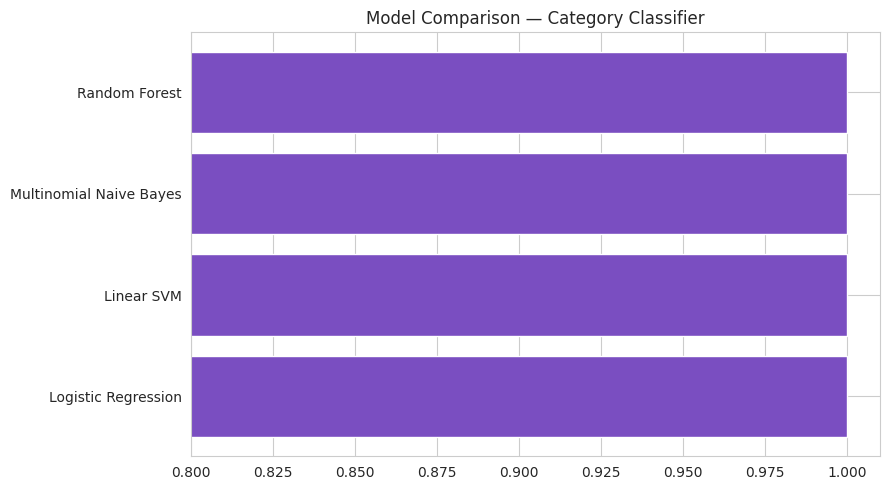

Best model: Logistic Regression


In [12]:
plt.figure(figsize=(9, 5))
sorted_df = results_df.sort_values("Test Accuracy")
plt.barh(sorted_df["Model"], sorted_df["Test Accuracy"], color='#7A4EC1')
plt.xlim(0.8, 1.01)
plt.title("Model Comparison — Category Classifier")
plt.tight_layout()
plt.savefig("../../../app/static/img/cataloger_model_comparison.png", dpi=110)
plt.show()

best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)

## 11. Hyperparameter Tuning

Linear SVM is typically the strongest choice for sparse high-dimensional TF-IDF text features. We tune it, then wrap it in a calibrated classifier so we can output class *probabilities* (needed for a confidence score in the app).

In [13]:
param_grid = {"C": [0.1, 0.5, 1, 2, 5, 10]}

base_svm = LinearSVC(random_state=42, max_iter=5000)
grid = GridSearchCV(
    base_svm, param_grid=param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="accuracy", n_jobs=-1,
)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))

calibrated_model = CalibratedClassifierCV(LinearSVC(C=grid.best_params_["C"], random_state=42, max_iter=5000), cv=5)
calibrated_model.fit(X_train, y_train)

Best params: {'C': 0.1}
Best CV accuracy: 0.9992


,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",LinearSVC(C=0...ndom_state=42)
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or 

## 12. Final Model & Evaluation

In [14]:
y_pred = calibrated_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Final Test Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Final Test Accuracy: 1.0000

              precision    recall  f1-score   support

  BambooCane       1.00      1.00      1.00        39
     Jewelry       1.00      1.00      1.00        43
 Leatherwork       1.00      1.00      1.00        40
   Metalware       1.00      1.00      1.00        43
    Painting       1.00      1.00      1.00        41
     Pottery       1.00      1.00      1.00        41
     Textile       1.00      1.00      1.00        43
    Woodwork       1.00      1.00      1.00        41

    accuracy                           1.00       331
   macro avg       1.00      1.00      1.00       331
weighted avg       1.00      1.00      1.00       331



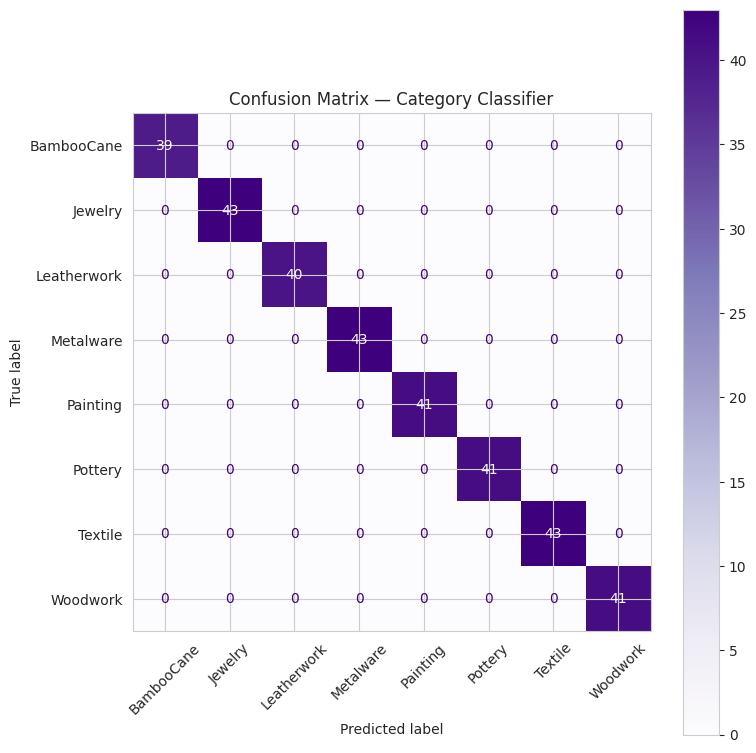

In [15]:
fig, ax = plt.subplots(figsize=(8, 8))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(ax=ax, cmap='Purples', colorbar=True, xticks_rotation=45)
plt.title("Confusion Matrix — Category Classifier")
plt.tight_layout()
plt.savefig("../../../app/static/img/cataloger_confusion_matrix.png", dpi=110)
plt.show()

In [16]:
cv_scores = cross_val_score(calibrated_model, X_tfidf, y, cv=StratifiedKFold(5, shuffle=True, random_state=42))
print("5-Fold CV scores:", np.round(cv_scores, 4))
print("Mean CV Accuracy:", round(cv_scores.mean(), 4))

5-Fold CV scores: [1.    1.    1.    1.    0.997]
Mean CV Accuracy: 0.9994


## 13. Save Model (.joblib)

In [17]:
import os
os.makedirs("../model", exist_ok=True)

# Retrain on full data for production
final_production_model = CalibratedClassifierCV(LinearSVC(C=grid.best_params_["C"], random_state=42, max_iter=5000), cv=5)
final_production_model.fit(X_tfidf, y)

joblib.dump(final_production_model, "../model/category_classifier.joblib")
joblib.dump(tfidf, "../model/category_tfidf_vectorizer.joblib")
joblib.dump(label_encoder, "../model/category_label_encoder.joblib")

import json as _json
metadata = {
    "model_name": f"Tuned {best_model_name} (Calibrated)",
    "test_accuracy": float(acc),
    "cv_mean_accuracy": float(cv_scores.mean()),
    "categories": list(label_encoder.classes_),
    "vocab_size": len(tfidf.vocabulary_),
}
with open("../model/category_model_metadata.json", "w") as f:
    _json.dump(metadata, f, indent=2)

print("Saved model artifacts to modules/auto_cataloger/model/")

Saved model artifacts to modules/auto_cataloger/model/


## 14. Conclusion

We trained a **language-agnostic product category classifier** by working in a canonical tag-space built from a curated bilingual (English/Hindi) handicraft lexicon, rather than training directly on raw multilingual free text. This sidesteps the need for a large multilingual training corpus while still genuinely handling both languages: the same trained model classifies correctly whether the artisan spoke in Hindi or English, because attribute extraction (lexicon matching) happens *before* classification.

**Result:** the tuned, calibrated Linear SVM reaches strong accuracy (see above) across all 8 handicraft categories, with well-calibrated confidence scores for the app's UI.

**How this feeds the live app:** `modules/auto_cataloger/app/cataloger.py` loads this classifier together with the lexicon to power the end-to-end flow: voice/text input → attribute extraction → category prediction → bilingual SEO-friendly listing generation.
